<a href="https://colab.research.google.com/github/Jashwanth248/ai-hw-Spring-2026-nn/blob/main/MRP_Similar_Face_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install datasets torch torchvision scikit-learn matplotlib pandas numpy pillow

# 2. Import libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


# 3. Load CelebA face attribute dataset

In [ ]:
# This uses a Hugging Face version of CelebA.
# If loading is slow, reduce MAX_SAMPLES below.

print("Loading CelebA dataset...")

try:
    raw_dataset = load_dataset("nateraw/celeba", split="train")
except:
    raw_dataset = load_dataset("negedng/CelebA-attrs-identity", split="train")

print(raw_dataset)
print("Columns:", raw_dataset.column_names)
print("Total samples:", len(raw_dataset))


# 4. Detect image column

In [4]:
possible_image_cols = ["image", "img", "jpg", "file"]

IMAGE_COL = None

for col in possible_image_cols:
    if col in raw_dataset.column_names:
        IMAGE_COL = col
        break

if IMAGE_COL is None:
    raise ValueError("Could not find image column. Please check dataset columns.")

print("Image column:", IMAGE_COL)


Image column: image


# 5. CelebA attribute names

In [5]:
CELEBA_ATTRS = [
    "5_o_Clock_Shadow",
    "Arched_Eyebrows",
    "Attractive",
    "Bags_Under_Eyes",
    "Bald",
    "Bangs",
    "Big_Lips",
    "Big_Nose",
    "Black_Hair",
    "Blond_Hair",
    "Blurry",
    "Brown_Hair",
    "Bushy_Eyebrows",
    "Chubby",
    "Double_Chin",
    "Eyeglasses",
    "Goatee",
    "Gray_Hair",
    "Heavy_Makeup",
    "High_Cheekbones",
    "Male",
    "Mouth_Slightly_Open",
    "Mustache",
    "Narrow_Eyes",
    "No_Beard",
    "Oval_Face",
    "Pale_Skin",
    "Pointy_Nose",
    "Receding_Hairline",
    "Rosy_Cheeks",
    "Sideburns",
    "Smiling",
    "Straight_Hair",
    "Wavy_Hair",
    "Wearing_Earrings",
    "Wearing_Hat",
    "Wearing_Lipstick",
    "Wearing_Necklace",
    "Wearing_Necktie",
    "Young"
]

# We use safer/non-identifying visual attributes.
# We avoid identity/name matching.
SAFE_ATTRIBUTES = [
    "Young",
    "Eyeglasses",
    "Smiling",
    "Bald",
    "Bangs",
    "Black_Hair",
    "Blond_Hair",
    "Brown_Hair",
    "Gray_Hair",
    "Straight_Hair",
    "Wavy_Hair",
    "Mustache",
    "No_Beard",
    "Wearing_Hat"
]

TARGET_ATTRIBUTE = "Eyeglasses"

print("Target attribute for training:", TARGET_ATTRIBUTE)
print("Attributes used for match percentage:", SAFE_ATTRIBUTES)


Target attribute for training: Eyeglasses
Attributes used for match percentage: ['Young', 'Eyeglasses', 'Smiling', 'Bald', 'Bangs', 'Black_Hair', 'Blond_Hair', 'Brown_Hair', 'Gray_Hair', 'Straight_Hair', 'Wavy_Hair', 'Mustache', 'No_Beard', 'Wearing_Hat']


# 6. Robust attribute reader

In [6]:
def to_binary_value(value):
    """
    Converts CelebA-style labels to 0/1.
    CelebA may store labels as:
    - 1 and -1
    - True and False
    - 1 and 0
    """
    if isinstance(value, bool):
        return int(value)

    try:
        value = int(value)
    except:
        return 0

    if value == -1:
        return 0

    if value > 0:
        return 1

    return 0


def get_attr(item, attr_name):
    """
    Reads an attribute from different possible CelebA dataset formats.
    """

    # Case 1: attribute is direct column
    if attr_name in item:
        return to_binary_value(item[attr_name])

    # Case 2: attribute dictionary column
    for key in ["attributes", "attrs", "attr"]:
        if key in item:
            attr_data = item[key]

            if isinstance(attr_data, dict):
                if attr_name in attr_data:
                    return to_binary_value(attr_data[attr_name])

            if isinstance(attr_data, list):
                if len(attr_data) == len(CELEBA_ATTRS):
                    idx = CELEBA_ATTRS.index(attr_name)
                    return to_binary_value(attr_data[idx])

    # Case 3: columns may use lowercase
    lower_map = {str(k).lower(): k for k in item.keys()}
    if attr_name.lower() in lower_map:
        return to_binary_value(item[lower_map[attr_name.lower()]])

    raise ValueError(f"Could not find attribute: {attr_name}")


# Test attribute reading
sample_item = raw_dataset[0]

print("Testing attribute reading:")
for attr in ["Eyeglasses", "Young", "Smiling"]:
    try:
        print(attr, "=", get_attr(sample_item, attr))
    except Exception as e:
        print("Error reading", attr, ":", e)


Testing attribute reading:
Eyeglasses = 0
Young = 1
Smiling = 1


# 7. Use smaller subset for faster Colab training

In [7]:
MAX_SAMPLES = 8000

dataset = raw_dataset.shuffle(seed=RANDOM_STATE).select(
    range(min(MAX_SAMPLES, len(raw_dataset)))
)

print("Samples used:", len(dataset))



Samples used: 8000


# 8. Image transforms

In [8]:
IMAGE_SIZE = 64

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])



# 9. Dataset class

In [9]:
class FaceAttributeDataset(Dataset):
    def __init__(self, hf_dataset, indices, transform=None):
        self.data = hf_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = int(self.indices[idx])
        item = self.data[real_idx]

        image = item[IMAGE_COL]

        if not isinstance(image, Image.Image):
            image = Image.fromarray(np.array(image))

        image = image.convert("RGB")

        if self.transform:
            image_tensor = self.transform(image)
        else:
            image_tensor = transforms.ToTensor()(image)

        label = get_attr(item, TARGET_ATTRIBUTE)

        attr_vector = torch.tensor(
            [get_attr(item, attr) for attr in SAFE_ATTRIBUTES],
            dtype=torch.float32
        )

        return {
            "image": image_tensor,
            "label": torch.tensor(label, dtype=torch.long),
            "attributes": attr_vector,
            "index": torch.tensor(real_idx, dtype=torch.long)
        }


# 10. Train-test split

In [10]:
labels = np.array([get_attr(dataset[i], TARGET_ATTRIBUTE) for i in range(len(dataset))])
indices = np.arange(len(dataset))

print("Target distribution:")
print(pd.Series(labels).value_counts())

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=labels
)

train_dataset = FaceAttributeDataset(dataset, train_idx, transform=train_transform)
test_dataset = FaceAttributeDataset(dataset, test_idx, transform=test_transform)

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


Target distribution:
0    7471
1     529
Name: count, dtype: int64
Train samples: 6000
Test samples: 2000


# 11. Helper functions for displaying images

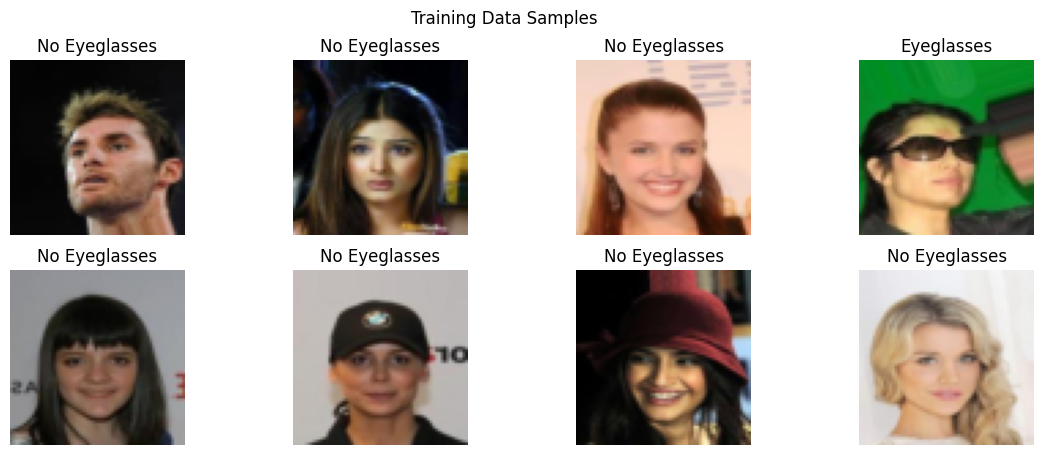

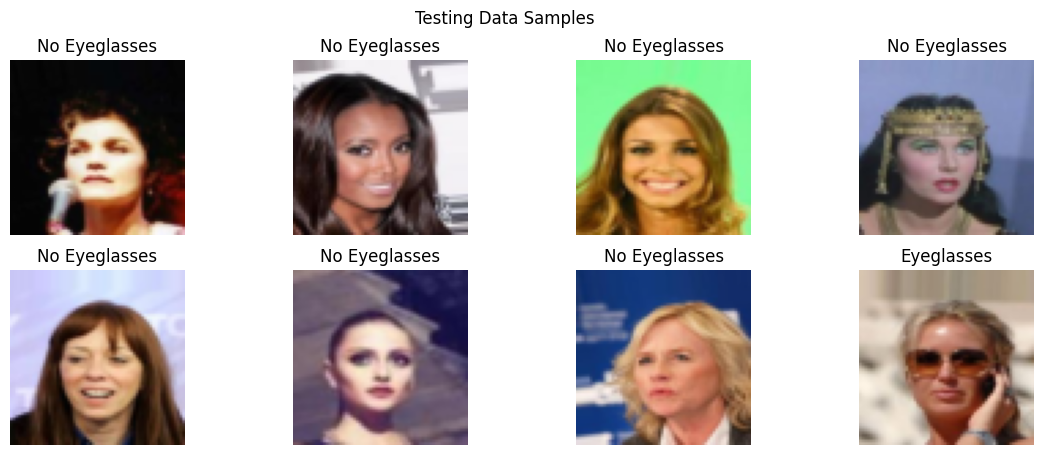

In [11]:
def denormalize_image(tensor_img):
    img = tensor_img.clone().detach().cpu()
    img = img * 0.5 + 0.5
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    return img


def show_image_grid(loader, title, n=8):
    batch = next(iter(loader))

    plt.figure(figsize=(14, 5))

    for i in range(min(n, len(batch["image"]))):
        img = denormalize_image(batch["image"][i])
        label = int(batch["label"][i].item())

        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title("Eyeglasses" if label == 1 else "No Eyeglasses")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()


show_image_grid(train_loader, "Training Data Samples")
show_image_grid(test_loader, "Testing Data Samples")


# 12. Model 1: MLP Neural Network

In [12]:
class FaceMLP(nn.Module):
    def __init__(self, image_size=64):
        super().__init__()

        input_dim = 3 * image_size * image_size

        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.net(x)


# 13. Model 2: CNN Image Recognition

In [13]:
class FaceCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


# 14. Model 3: Vision Transformer-style model

In [14]:
class FaceTransformer(nn.Module):
    def __init__(self, image_size=64, patch_size=8, embed_dim=128, num_heads=4, num_layers=2):
        super().__init__()

        self.num_patches = (image_size // patch_size) * (image_size // patch_size)

        self.patch_embedding = nn.Conv2d(
            in_channels=3,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        self.position_embedding = nn.Parameter(
            torch.randn(1, self.num_patches, embed_dim)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            batch_first=True,
            dropout=0.20
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.classifier = nn.Linear(embed_dim, 2)

    def forward(self, x):
        x = self.patch_embedding(x)
        x = x.flatten(2).permute(0, 2, 1)
        x = x + self.position_embedding
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.classifier(x)


# 15. Training and evaluation functions

In [15]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for batch in loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate_model(model, loader):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []
    all_indices = []

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_indices.extend(batch["index"].cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return (
        acc,
        precision,
        recall,
        f1,
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs),
        np.array(all_indices)
    )


# 16. Class weights

In [16]:


train_labels = labels[train_idx]
class_counts = np.bincount(train_labels)

if len(class_counts) < 2:
    class_counts = np.array([len(train_labels), 1])

class_weights = len(train_labels) / (2.0 * class_counts)

# Reduce positive class weight slightly.
# This helps the model stop predicting "Eyeglasses" too often.
class_weights[1] = class_weights[1] * 0.7

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class counts:", class_counts)
print("Adjusted class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

Class counts: [5603  397]
Adjusted class weights: tensor([0.5354, 5.2897])


# 17. Train MLP, CNN, and Transformer

In [17]:
EPOCHS = 10
LEARNING_RATE = 0.001

models = {
    "MLP Neural Network": FaceMLP(IMAGE_SIZE),
    "CNN Image Recognition": FaceCNN(),
    "Transformer": FaceTransformer(IMAGE_SIZE)
}

results = {}
trained_models = {}

for name, model in models.items():
    print("\n==============================")
    print("Training:", name)
    print("==============================")

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_f1 = 0
    best_state = None

    for epoch in range(EPOCHS):
        loss = train_one_epoch(model, train_loader, optimizer, criterion)

        acc, precision, recall, f1, y_true, y_pred, y_prob, y_indices = evaluate_model(
            model,
            test_loader
        )

        print(
            f"Epoch {epoch+1:02d}/{EPOCHS} | "
            f"Loss={loss:.4f} | "
            f"Acc={acc:.3f} | "
            f"Precision={precision:.3f} | "
            f"Recall={recall:.3f} | "
            f"F1={f1:.3f}"
        )

        if f1 > best_f1:
            best_f1 = f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    acc, precision, recall, f1, y_true, y_pred, y_prob, y_indices = evaluate_model(
        model,
        test_loader
    )

    results[name] = {
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

    trained_models[name] = model

results_df = pd.DataFrame(results).T.sort_values("F1", ascending=False)

print("\nFinal Model Comparison:")
display(results_df)

best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)



Training: MLP Neural Network
Epoch 01/10 | Loss=0.7753 | Acc=0.874 | Precision=0.273 | Recall=0.545 | F1=0.364
Epoch 02/10 | Loss=0.5293 | Acc=0.830 | Precision=0.234 | Recall=0.697 | F1=0.350
Epoch 03/10 | Loss=0.4347 | Acc=0.940 | Precision=0.541 | Recall=0.553 | F1=0.547
Epoch 04/10 | Loss=0.4080 | Acc=0.823 | Precision=0.223 | Recall=0.682 | F1=0.336
Epoch 05/10 | Loss=0.3798 | Acc=0.871 | Precision=0.308 | Recall=0.773 | F1=0.441
Epoch 06/10 | Loss=0.3661 | Acc=0.889 | Precision=0.328 | Recall=0.652 | F1=0.437
Epoch 07/10 | Loss=0.3302 | Acc=0.938 | Precision=0.519 | Recall=0.727 | F1=0.606
Epoch 08/10 | Loss=0.3382 | Acc=0.938 | Precision=0.522 | Recall=0.621 | F1=0.567
Epoch 09/10 | Loss=0.3338 | Acc=0.930 | Precision=0.478 | Recall=0.667 | F1=0.557
Epoch 10/10 | Loss=0.3210 | Acc=0.897 | Precision=0.361 | Recall=0.727 | F1=0.482

Training: CNN Image Recognition
Epoch 01/10 | Loss=0.6662 | Acc=0.842 | Precision=0.122 | Recall=0.227 | F1=0.159
Epoch 02/10 | Loss=0.5918 | Acc=0.8

,Accuracy,Precision,Recall,F1
CNN Image Recognition,0.9715,0.815126,0.734848,0.772908
MLP Neural Network,0.9375,0.518919,0.727273,0.605678
Transformer,0.8770,0.332353,0.856061,0.478814


Best model: CNN Image Recognition


# 18. Classification report and confusion matrix

Classification Report for Best Model:
               precision    recall  f1-score   support

No Eyeglasses       0.98      0.99      0.98      1868
   Eyeglasses       0.82      0.73      0.77       132

     accuracy                           0.97      2000
    macro avg       0.90      0.86      0.88      2000
 weighted avg       0.97      0.97      0.97      2000



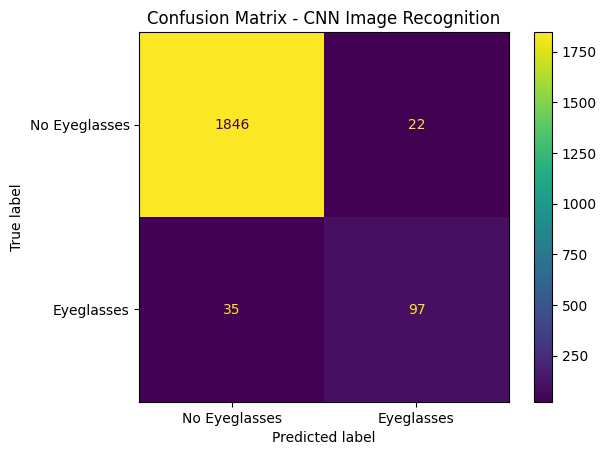

In [18]:
acc, precision, recall, f1, y_true, y_pred, y_prob, y_indices = evaluate_model(
    best_model,
    test_loader
)

print("Classification Report for Best Model:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["No Eyeglasses", "Eyeglasses"],
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Eyeglasses", "Eyeglasses"]
)

disp.plot(values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


18B. Threshold tuning improvement

Threshold tuning results:


,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.9560,0.620879,0.856061,0.719745
1,0.15,0.9645,0.689441,0.840909,0.757679
2,0.20,0.9650,0.698718,0.825758,0.756944
3,0.25,0.9680,0.736111,0.803030,0.768116
4,0.30,0.9695,0.751773,0.803030,0.776557
5,0.35,0.9690,0.761194,0.772727,0.766917
6,0.40,0.9705,0.782946,0.765152,0.773946
7,0.45,0.9705,0.796748,0.742424,0.768627
8,0.50,0.9715,0.815126,0.734848,0.772908
9,0.55,0.9705,0.817391,0.712121,0.761134


Best threshold based on F1 score: 0.3


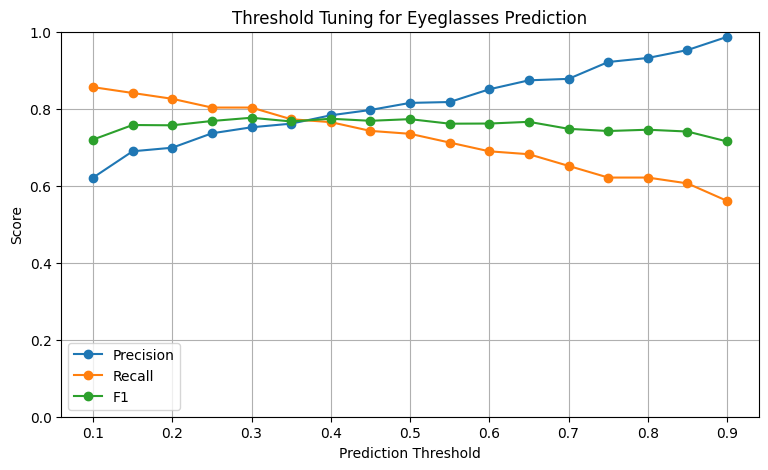

In [19]:
def evaluate_model_with_threshold(model, loader, threshold=0.50):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1]

            preds = (probs >= threshold).long()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return acc, precision, recall, f1, np.array(all_labels), np.array(all_preds), np.array(all_probs)


thresholds = np.arange(0.10, 0.91, 0.05)
threshold_results = []

for threshold in thresholds:
    acc_t, precision_t, recall_t, f1_t, y_true_t, y_pred_t, y_prob_t = evaluate_model_with_threshold(
        best_model,
        test_loader,
        threshold=threshold
    )

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": acc_t,
        "Precision": precision_t,
        "Recall": recall_t,
        "F1": f1_t
    })

threshold_df = pd.DataFrame(threshold_results)

print("Threshold tuning results:")
display(threshold_df)

best_threshold = threshold_df.sort_values("F1", ascending=False).iloc[0]["Threshold"]

print("Best threshold based on F1 score:", best_threshold)

plt.figure(figsize=(9, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], marker="o", label="F1")

plt.title("Threshold Tuning for Eyeglasses Prediction")
plt.xlabel("Prediction Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()


18C. Improved classification report

Improved Classification Report using best threshold:
               precision    recall  f1-score   support

No Eyeglasses       0.99      0.98      0.98      1868
   Eyeglasses       0.75      0.80      0.78       132

     accuracy                           0.97      2000
    macro avg       0.87      0.89      0.88      2000
 weighted avg       0.97      0.97      0.97      2000



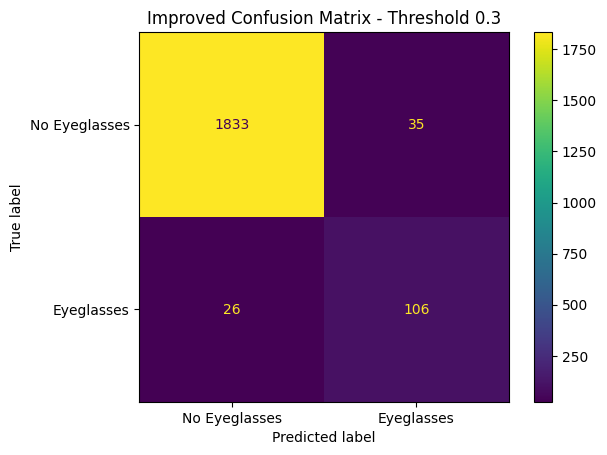

Before vs After Threshold Tuning:


,Metric,Before Threshold Tuning,After Threshold Tuning
0,Accuracy,0.971500,0.969500
1,Precision,0.815126,0.751773
2,Recall,0.734848,0.803030
3,F1,0.772908,0.776557


In [20]:
acc_new, precision_new, recall_new, f1_new, y_true_new, y_pred_new, y_prob_new = evaluate_model_with_threshold(
    best_model,
    test_loader,
    threshold=best_threshold
)

print("Improved Classification Report using best threshold:")
print(classification_report(
    y_true_new,
    y_pred_new,
    target_names=["No Eyeglasses", "Eyeglasses"],
    zero_division=0
))

cm_new = confusion_matrix(y_true_new, y_pred_new)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_new,
    display_labels=["No Eyeglasses", "Eyeglasses"]
)

disp.plot(values_format="d")
plt.title(f"Improved Confusion Matrix - Threshold {best_threshold}")
plt.show()

before_after_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1"],
    "Before Threshold Tuning": [
        results_df.loc[best_model_name, "Accuracy"],
        results_df.loc[best_model_name, "Precision"],
        results_df.loc[best_model_name, "Recall"],
        results_df.loc[best_model_name, "F1"]
    ],
    "After Threshold Tuning": [
        acc_new,
        precision_new,
        recall_new,
        f1_new
    ]
})

print("Before vs After Threshold Tuning:")
display(before_after_df)


# 19. Show final prediction images

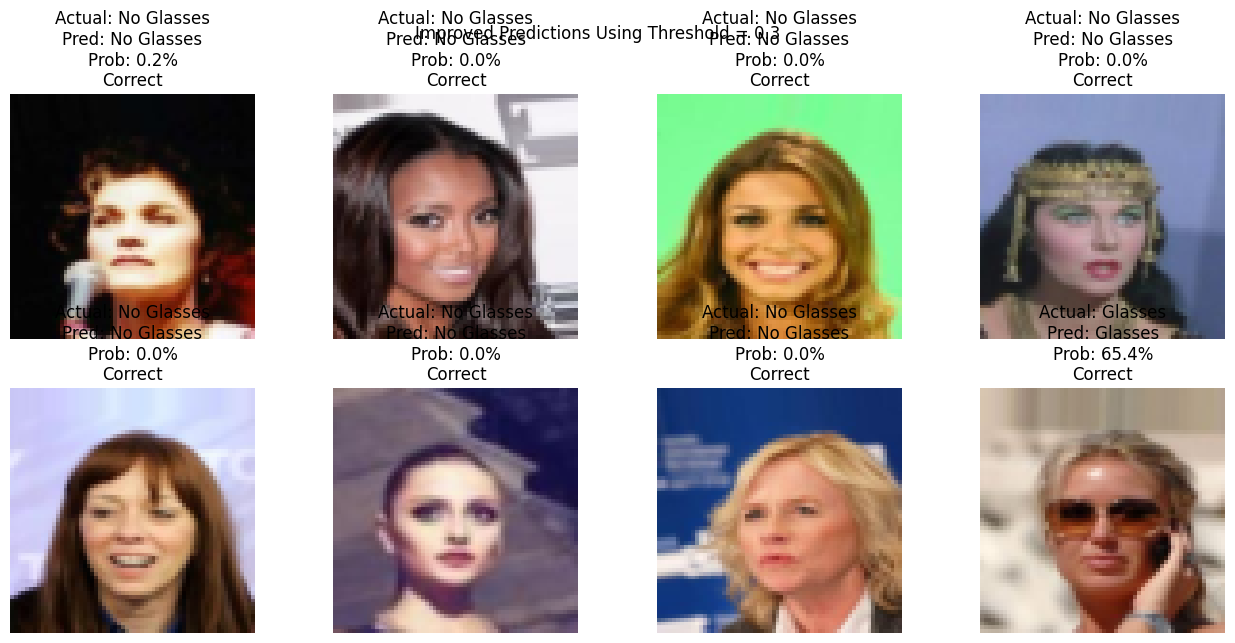

In [21]:
def show_prediction_images_with_threshold(model, loader, threshold, n=8):
    model.eval()

    batch = next(iter(loader))

    images = batch["image"].to(device)
    labels = batch["label"].cpu().numpy()

    with torch.no_grad():
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        preds = (probs >= threshold).astype(int)

    plt.figure(figsize=(16, 7))

    for i in range(min(n, len(images))):
        img = denormalize_image(batch["image"][i])

        actual = "Glasses" if labels[i] == 1 else "No Glasses"
        predicted = "Glasses" if preds[i] == 1 else "No Glasses"
        prob = probs[i] * 100

        correct = "Correct" if labels[i] == preds[i] else "Wrong"

        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(
            f"Actual: {actual}\nPred: {predicted}\nProb: {prob:.1f}%\n{correct}"
        )
        plt.axis("off")


    plt.show()


show_prediction_images_with_threshold(best_model, test_loader, best_threshold, n=8)




# 20. Eye-region color similarity

In [22]:


def get_original_pil_image(item):
    image = item[IMAGE_COL]

    if not isinstance(image, Image.Image):
        image = Image.fromarray(np.array(image))

    return image.convert("RGB")


def crop_region_feature(pil_img, region_name):
    """
    Uses approximate face regions from aligned CelebA images.
    This gives visual similarity, not identity recognition.
    """

    img = pil_img.resize((128, 128)).convert("RGB")
    arr = np.array(img).astype(np.float32) / 255.0

    if region_name == "hair":
        crop = arr[0:40, 25:105, :]

    elif region_name == "eyes":
        crop = arr[38:65, 25:105, :]

    elif region_name == "nose":
        crop = arr[55:90, 45:83, :]

    elif region_name == "mouth":
        crop = arr[85:115, 35:95, :]

    elif region_name == "full_face":
        crop = arr[15:120, 15:113, :]

    else:
        crop = arr

    hist_features = []

    for channel in range(3):
        hist, _ = np.histogram(
            crop[:, :, channel],
            bins=16,
            range=(0, 1),
            density=True
        )
        hist_features.extend(hist)

    feature = np.array(hist_features, dtype=np.float32)
    feature = feature / (np.linalg.norm(feature) + 1e-8)

    return feature


def cosine_similarity_percent(vec_a, vec_b):
    sim = np.dot(vec_a, vec_b) / ((np.linalg.norm(vec_a) * np.linalg.norm(vec_b)) + 1e-8)
    sim = np.clip(sim, 0, 1)
    return float(sim * 100)


def binary_match_percent(value_a, value_b):
    """
    Fixed: works for text labels and numeric labels.
    """
    return 100.0 if str(value_a) == str(value_b) else 0.0


def group_hair_color(item):
    if get_attr(item, "Black_Hair") == 1:
        return "Black Hair"
    if get_attr(item, "Blond_Hair") == 1:
        return "Blond Hair"
    if get_attr(item, "Brown_Hair") == 1:
        return "Brown Hair"
    if get_attr(item, "Gray_Hair") == 1:
        return "Gray Hair"
    if get_attr(item, "Bald") == 1:
        return "Bald"
    return "Other/Unknown"


def group_hair_type(item):
    if get_attr(item, "Bald") == 1:
        return "Bald"
    if get_attr(item, "Wavy_Hair") == 1:
        return "Wavy Hair"
    if get_attr(item, "Straight_Hair") == 1:
        return "Straight Hair"
    if get_attr(item, "Bangs") == 1:
        return "Bangs"
    return "Other/Unknown"


def nose_group(item):
    big = get_attr(item, "Big_Nose")
    pointy = get_attr(item, "Pointy_Nose")

    if big == 1 and pointy == 1:
        return "Big and Pointy Nose"
    if big == 1:
        return "Big Nose"
    if pointy == 1:
        return "Pointy Nose"
    return "Other/Normal Nose"


def eye_group(item):
    narrow = get_attr(item, "Narrow_Eyes")
    return "Narrow Eyes" if narrow == 1 else "Other/Normal Eyes"


def age_group(item):
    return "Young" if get_attr(item, "Young") == 1 else "Not Young"


def glasses_group(item):
    return "Eyeglasses" if get_attr(item, "Eyeglasses") == 1 else "No Eyeglasses"


def smile_group(item):
    return "Smiling" if get_attr(item, "Smiling") == 1 else "Not Smiling"


def beard_group(item):
    return "No Beard" if get_attr(item, "No_Beard") == 1 else "Beard/Facial Hair"


def hat_group(item):
    return "Hat" if get_attr(item, "Wearing_Hat") == 1 else "No Hat"


def face_similarity_report(item_a, item_b):
    """
    Compares two face images using:
    1. Region-based visual similarity
    2. Attribute-based label matching
    """

    image_a = get_original_pil_image(item_a)
    image_b = get_original_pil_image(item_b)

    report_rows = []

    region_names = ["hair", "eyes", "nose", "mouth", "full_face"]

    for region in region_names:
        feat_a = crop_region_feature(image_a, region)
        feat_b = crop_region_feature(image_b, region)

        score = cosine_similarity_percent(feat_a, feat_b)

        report_rows.append({
            "Feature": f"{region.capitalize()} visual similarity",
            "Image A": "Region feature",
            "Image B": "Region feature",
            "Match %": round(score, 2)
        })

    label_features = [
        ("Hair color", group_hair_color(item_a), group_hair_color(item_b)),
        ("Hair type", group_hair_type(item_a), group_hair_type(item_b)),
        ("Nose feature", nose_group(item_a), nose_group(item_b)),
        ("Eye feature", eye_group(item_a), eye_group(item_b)),
        ("Age group", age_group(item_a), age_group(item_b)),
        ("Eyeglasses", glasses_group(item_a), glasses_group(item_b)),
        ("Smile", smile_group(item_a), smile_group(item_b)),
        ("Beard", beard_group(item_a), beard_group(item_b)),
        ("Hat", hat_group(item_a), hat_group(item_b))
    ]

    for feature_name, value_a, value_b in label_features:
        report_rows.append({
            "Feature": feature_name,
            "Image A": value_a,
            "Image B": value_b,
            "Match %": binary_match_percent(value_a, value_b)
        })

    report_df = pd.DataFrame(report_rows)

    weights = {
        "Hair visual similarity": 1.5,
        "Eyes visual similarity": 1.5,
        "Nose visual similarity": 1.5,
        "Mouth visual similarity": 1.0,
        "Full_face visual similarity": 2.0,
        "Hair color": 1.2,
        "Hair type": 1.0,
        "Nose feature": 1.2,
        "Eye feature": 1.0,
        "Age group": 0.8,
        "Eyeglasses": 0.8,
        "Smile": 0.6,
        "Beard": 0.8,
        "Hat": 0.4
    }

    weighted_sum = 0
    total_weight = 0

    for _, row in report_df.iterrows():
        feature_name = row["Feature"]
        match_score = float(row["Match %"])
        weight = weights.get(feature_name, 1.0)

        weighted_sum += match_score * weight
        total_weight += weight

    overall_match = weighted_sum / total_weight

    return report_df, overall_match


# Optional alias, so old code also works
attribute_match_report = face_similarity_report

print(" face_similarity_report and attribute_match_report are now defined.")

 face_similarity_report and attribute_match_report are now defined.


# 21. Show attribute match between two images

Overall visual face similarity match: 54.72%
This is visual attribute similarity, not identity recognition.


,Feature,Image A,Image B,Match %
0,Hair visual similarity,Region feature,Region feature,44.59
1,Eyes visual similarity,Region feature,Region feature,34.87
2,Nose visual similarity,Region feature,Region feature,29.25
3,Mouth visual similarity,Region feature,Region feature,61.59
4,Full_face visual similarity,Region feature,Region feature,56.31
5,Hair color,Brown Hair,Other/Unknown,0.00
6,Hair type,Other/Unknown,Wavy Hair,0.00
7,Nose feature,Other/Normal Nose,Other/Normal Nose,100.00
8,Eye feature,Other/Normal Eyes,Other/Normal Eyes,100.00
9,Age group,Young,Young,100.00


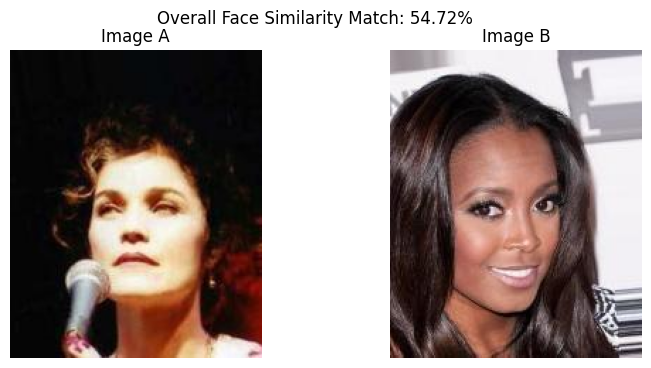

In [23]:
# ============================================================
# 21. Show attribute / visual match between two images
# ============================================================

item_a = dataset[int(test_idx[0])]
item_b = dataset[int(test_idx[1])]

# Use the correct updated function name
match_df, overall_match = face_similarity_report(item_a, item_b)

print(f"Overall visual face similarity match: {overall_match:.2f}%")
print("This is visual attribute similarity, not identity recognition.")

display(match_df)

plt.figure(figsize=(9, 4))

plt.subplot(1, 2, 1)
plt.imshow(get_original_pil_image(item_a))
plt.title("Image A")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(get_original_pil_image(item_b))
plt.title("Image B")
plt.axis("off")

plt.suptitle(f"Overall Face Similarity Match: {overall_match:.2f}%")
plt.show()

# 22. Find best attribute match from dataset

Best attribute match found in first 500 images
Best overall match: 82.75%
This is not person identification. It is only attribute similarity.


,Feature,Image A,Image B,Match %
0,Hair visual similarity,Region feature,Region feature,58.49
1,Eyes visual similarity,Region feature,Region feature,88.25
2,Nose visual similarity,Region feature,Region feature,95.41
3,Mouth visual similarity,Region feature,Region feature,67.29
4,Full_face visual similarity,Region feature,Region feature,87.75
5,Hair color,Brown Hair,Other/Unknown,0.00
6,Hair type,Other/Unknown,Other/Unknown,100.00
7,Nose feature,Other/Normal Nose,Other/Normal Nose,100.00
8,Eye feature,Other/Normal Eyes,Other/Normal Eyes,100.00
9,Age group,Young,Young,100.00


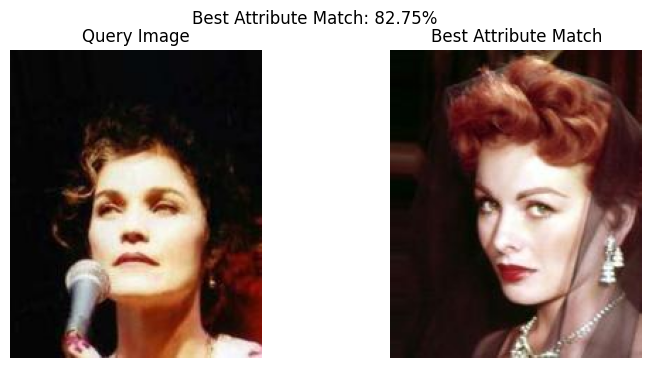

In [24]:
query_item = dataset[int(test_idx[0])]

best_score = -1
best_item = None
best_df = None
best_index = None

SEARCH_LIMIT = min(500, len(dataset))

for i in range(SEARCH_LIMIT):
    if i == int(test_idx[0]):
        continue

    candidate_item = dataset[i]

    temp_df, temp_score = attribute_match_report(query_item, candidate_item)

    if temp_score > best_score:
        best_score = temp_score
        best_item = candidate_item
        best_df = temp_df
        best_index = i

print(f"Best attribute match found in first {SEARCH_LIMIT} images")
print(f"Best overall match: {best_score:.2f}%")
print("This is not person identification. It is only attribute similarity.")

display(best_df)

plt.figure(figsize=(9, 4))

plt.subplot(1, 2, 1)
plt.imshow(get_original_pil_image(query_item))
plt.title("Query Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(get_original_pil_image(best_item))
plt.title("Best Attribute Match")
plt.axis("off")

plt.suptitle(f"Best Attribute Match: {best_score:.2f}%")
plt.show()


# 23. Show predicted result with attribute match percentages

Query image prediction:
Predicted: No Eyeglasses
Eyeglasses probability: 0.17 %

Best match image prediction:
Predicted: No Eyeglasses
Eyeglasses probability: 0.14 %


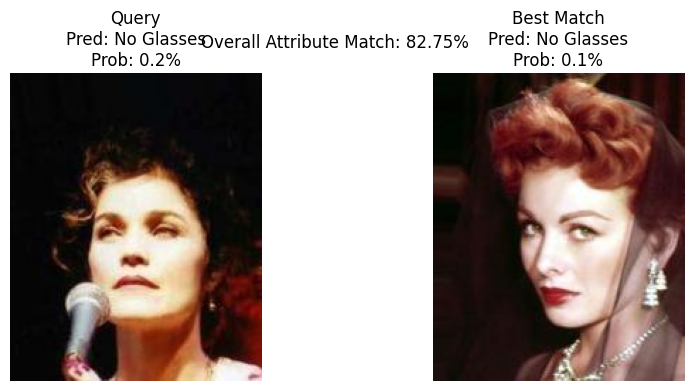

In [25]:
def predict_single_image(model, item):
    image = get_original_pil_image(item)
    image_tensor = test_transform(image).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        output = model(image_tensor)
        prob = torch.softmax(output, dim=1)[0, 1].item()
        pred = torch.argmax(output, dim=1).item()

    return pred, prob


pred_a, prob_a = predict_single_image(best_model, query_item)
pred_b, prob_b = predict_single_image(best_model, best_item)

print("Query image prediction:")
print("Predicted:", "Eyeglasses" if pred_a == 1 else "No Eyeglasses")
print("Eyeglasses probability:", round(prob_a * 100, 2), "%")

print("\nBest match image prediction:")
print("Predicted:", "Eyeglasses" if pred_b == 1 else "No Eyeglasses")
print("Eyeglasses probability:", round(prob_b * 100, 2), "%")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(get_original_pil_image(query_item))
plt.title(
    f"Query\nPred: {'Glasses' if pred_a == 1 else 'No Glasses'}\nProb: {prob_a*100:.1f}%"
)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(get_original_pil_image(best_item))
plt.title(
    f"Best Match\nPred: {'Glasses' if pred_b == 1 else 'No Glasses'}\nProb: {prob_b*100:.1f}%"
)
plt.axis("off")

plt.suptitle(f"Overall Attribute Match: {best_score:.2f}%")
plt.show()


# 24. Explainable AI: saliency map

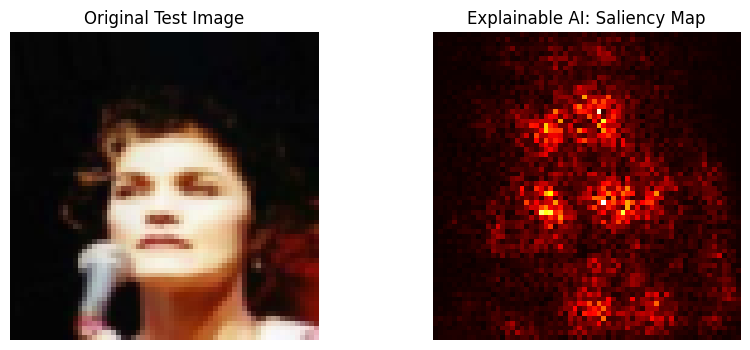

In [26]:
def create_saliency_map(model, image_tensor, class_index):
    model.eval()

    image = image_tensor.unsqueeze(0).to(device)
    image.requires_grad_()

    output = model(image)
    score = output[0, class_index]

    model.zero_grad()
    score.backward()

    saliency = image.grad.abs().squeeze().detach().cpu()
    saliency, _ = torch.max(saliency, dim=0)

    return saliency.numpy()


example_batch = next(iter(test_loader))
example_image = example_batch["image"][0]
example_label = int(example_batch["label"][0].item())

saliency = create_saliency_map(best_model, example_image, example_label)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(denormalize_image(example_image))
plt.title("Original Test Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(saliency, cmap="hot")
plt.title("Explainable AI: Saliency Map")
plt.axis("off")

plt.show()


# 25. Noise robustness testing

Robustness test results:


,Noise Level,Accuracy,Precision,Recall,F1
0,0.00,0.9715,0.815126,0.734848,0.772908
1,0.05,0.9620,0.672840,0.825758,0.741497
2,0.10,0.8835,0.354467,0.931818,0.513570
3,0.20,0.5860,0.128998,0.916667,0.226168
4,0.30,0.4585,0.098734,0.886364,0.177677


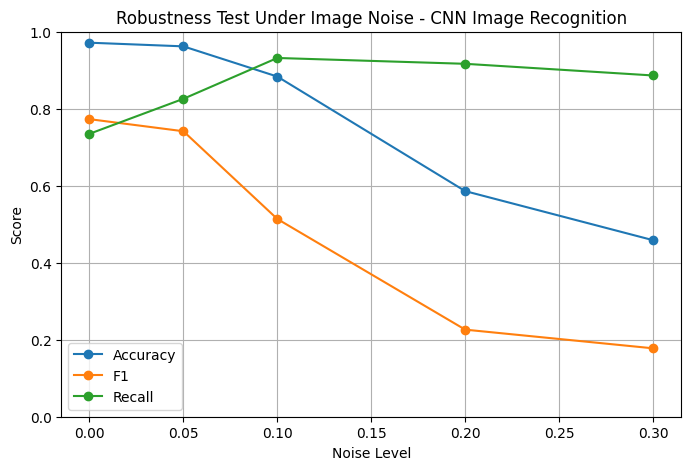

In [27]:
def evaluate_with_noise(model, loader, noise_level):
    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

            noisy_images = images + torch.randn_like(images) * noise_level
            noisy_images = torch.clamp(noisy_images, -1, 1)

            outputs = model(noisy_images)
            preds = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return acc, precision, recall, f1


noise_levels = [0.00, 0.05, 0.10, 0.20, 0.30]
robustness_results = []

for noise in noise_levels:
    acc_n, precision_n, recall_n, f1_n = evaluate_with_noise(
        best_model,
        test_loader,
        noise
    )

    robustness_results.append({
        "Noise Level": noise,
        "Accuracy": acc_n,
        "Precision": precision_n,
        "Recall": recall_n,
        "F1": f1_n
    })

robustness_df = pd.DataFrame(robustness_results)

print("Robustness test results:")
display(robustness_df)

plt.figure(figsize=(8, 5))
plt.plot(robustness_df["Noise Level"], robustness_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(robustness_df["Noise Level"], robustness_df["F1"], marker="o", label="F1")
plt.plot(robustness_df["Noise Level"], robustness_df["Recall"], marker="o", label="Recall")

plt.title(f"Robustness Test Under Image Noise - {best_model_name}")
plt.xlabel("Noise Level")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()



# 26. Show noisy image example

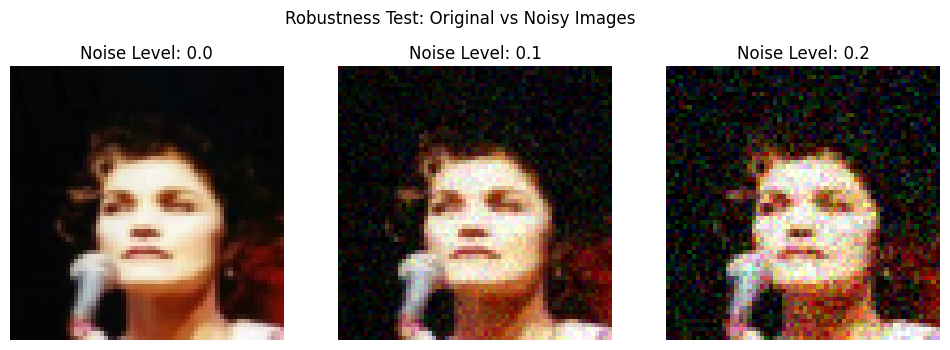

In [28]:
sample_img = example_batch["image"][0]

plt.figure(figsize=(12, 4))

for i, noise in enumerate([0.00, 0.10, 0.20]):
    noisy_img = sample_img + torch.randn_like(sample_img) * noise
    noisy_img = torch.clamp(noisy_img, -1, 1)

    plt.subplot(1, 3, i + 1)
    plt.imshow(denormalize_image(noisy_img))
    plt.title(f"Noise Level: {noise}")
    plt.axis("off")

plt.suptitle("Robustness Test: Original vs Noisy Images")
plt.show()

